# Student Performance Analysis



## 1) Load the dataset

Load`student-mat.csv`.  

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Optional: makes plots display a bit cleaner in notebooks
plt.style.use("default")

CSV_NAME = "student-mat.csv"

df = pd.read_csv(CSV_NAME, sep=";")

df.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


### Explanation of Step 1: Loading the Dataset

In this step, we use the `pandas` library to load the `student-mat.csv` file into a DataFrame named `df`. The `sep=";"` argument is crucial because the data in this CSV file is delimited by semicolons, not commas. The `df.head()` command then displays the first five rows of the DataFrame, giving us a quick preview of the data's structure and content.

## 2) Explore and clean the data

This section checks missing values, duplicate rows, shape, and data types, then removes duplicates.



In [2]:
# Basic inspection
print("Shape before cleaning:", df.shape)
print("\nData types:")
print(df.dtypes)

print("\nMissing values per column:")
print(df.isnull().sum())

print("\nDuplicate rows:", df.duplicated().sum())

# Clean duplicates only, as requested
clean_df = df.drop_duplicates().copy()

print("\nShape after removing duplicates:", clean_df.shape)

Shape before cleaning: (395, 33)

Data types:
school        object
sex           object
age            int64
address       object
famsize       object
Pstatus       object
Medu           int64
Fedu           int64
Mjob          object
Fjob          object
reason        object
guardian      object
traveltime     int64
studytime      int64
failures       int64
schoolsup     object
famsup        object
paid          object
activities    object
nursery       object
higher        object
internet      object
romantic      object
famrel         int64
freetime       int64
goout          int64
Dalc           int64
Walc           int64
health         int64
absences       int64
G1             int64
G2             int64
G3             int64
dtype: object

Missing values per column:
school        0
sex           0
age           0
address       0
famsize       0
Pstatus       0
Medu          0
Fedu          0
Mjob          0
Fjob          0
reason        0
guardian      0
traveltime    0
studytime  

### Explanation of Step 2: Explore and Clean the Data

This section focuses on understanding the basic characteristics of the dataset and performing initial cleaning. We perform the following checks:

*   **Shape Inspection:** We print the number of rows and columns before cleaning.
*   **Data Types:** We display the data type of each column to understand how different variables are represented.
*   **Missing Values:** We check for any missing values across all columns using `isnull().sum()`. In this dataset, there are no missing values.
*   **Duplicate Rows:** We identify if there are any identical rows in the dataset. Since no duplicates were found, the `clean_df` is essentially a copy of the original `df`.

The `df.drop_duplicates().copy()` operation creates a new DataFrame, `clean_df`, where any identical rows (if they existed) would have been removed. This ensures that our analysis is based on unique observations.

## 3) Analysis questions

The next cell computes the required answers:
- average final grade (`G3`)
- number of students scoring above 15
- correlation between study time and final grade
- which gender performs better on average



In [3]:
# 1) Average final grade
avg_g3 = clean_df["G3"].mean()

# 2) How many students scored above 15?
students_above_15 = (clean_df["G3"] > 15).sum()

# 3) Is study time correlated with performance?
# studytime is numeric in the dataset, so Pearson correlation is appropriate here
studytime_g3_corr = clean_df["studytime"].corr(clean_df["G3"])

# 4) Which gender performs better on average?
gender_avg = clean_df.groupby("sex")["G3"].mean().sort_values(ascending=False)

gender_label_map = {"M": "Male", "F": "Female"}
gender_avg_named = gender_avg.rename(index=gender_label_map)

better_gender_code = gender_avg.index[0]
better_gender_named = gender_label_map.get(better_gender_code, better_gender_code)

print(f"Average final grade (G3): {avg_g3:.2f}")
print(f"Students scoring above 15: {students_above_15}")
print(f"Correlation between study time and G3: {studytime_g3_corr:.4f}")
print("\nAverage G3 by gender:")
print(gender_avg_named)
print(f"\nGender with higher average score: {better_gender_named}")

Average final grade (G3): 10.42
Students scoring above 15: 40
Correlation between study time and G3: 0.0978

Average G3 by gender:
sex
Male      10.914439
Female     9.966346
Name: G3, dtype: float64

Gender with higher average score: Male


### Explanation of Step 3: Analysis Questions

In this step, we computed several key statistics to answer specific questions about student performance:

1.  **Average Final Grade (G3):** We calculated the mean of the `G3` column, which represents the final grade. The average final grade is approximately **10.42**.
2.  **Students Scoring Above 15:** We counted how many students achieved a final grade (`G3`) greater than 15. There are **40** such students.
3.  **Correlation between Study Time and Final Grade:** We calculated the Pearson correlation coefficient between `studytime` and `G3`. The correlation is approximately **0.0978**, which indicates a very weak positive linear relationship. This suggests that while there might be a slight tendency for students who study more to have higher grades, the relationship is not strong.
4.  **Gender Performance Comparison:** We grouped the data by `sex` and calculated the average final grade for males and females. The results show that **males have a slightly higher average final grade (10.91) compared to females (9.97)**.

## 4) Visualization 1 — Histogram of grades



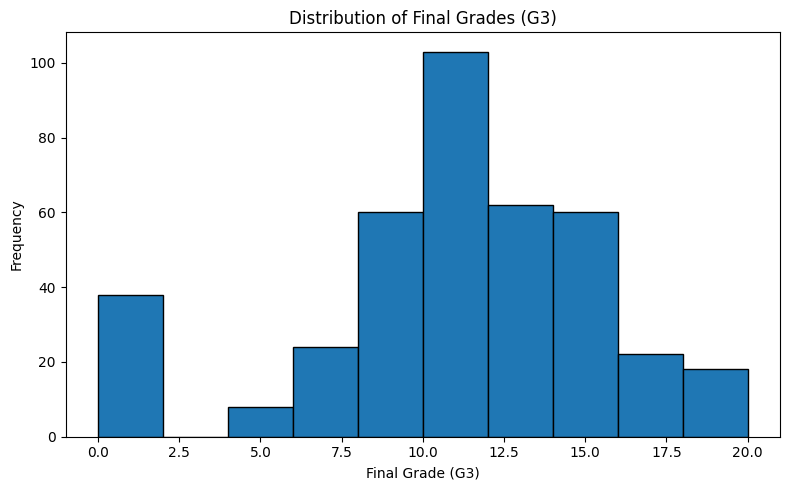

In [4]:
plt.figure(figsize=(8, 5))
plt.hist(clean_df["G3"], bins=10, edgecolor="black")
plt.title("Distribution of Final Grades (G3)")
plt.xlabel("Final Grade (G3)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

### Conclusion from Visualization 1: Histogram of Final Grades

The histogram of final grades (`G3`) shows that the distribution is left-skewed, meaning there are more students achieving lower grades than higher grades. The majority of students fall within the **8-12 grade range**, with a noticeable drop-off in the frequency of higher grades. This suggests that achieving very high scores (e.g., above 15) is less common, aligning with the earlier finding that only 40 students scored above 15.

## 5) Visualization 2 — Study time vs grades



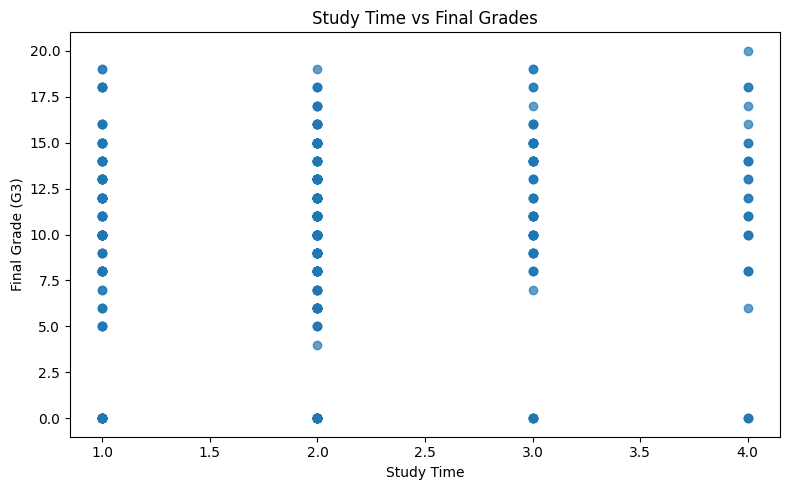

In [5]:
plt.figure(figsize=(8, 5))
plt.scatter(clean_df["studytime"], clean_df["G3"], alpha=0.7)
plt.title("Study Time vs Final Grades")
plt.xlabel("Study Time")
plt.ylabel("Final Grade (G3)")
plt.tight_layout()
plt.show()

### Conclusion from Visualization 2: Study Time vs Final Grades

The scatter plot illustrates the relationship between study time and final grades. Consistent with the calculated correlation coefficient (0.0978), the plot shows a **weak positive trend**. While there's a general tendency for higher study times to be associated with slightly higher grades, the points are widely scattered. This indicates that study time alone is not a strong predictor of final grades, and other factors likely play a more significant role in student performance.

## 6) Visualization 3 — Male vs female average score



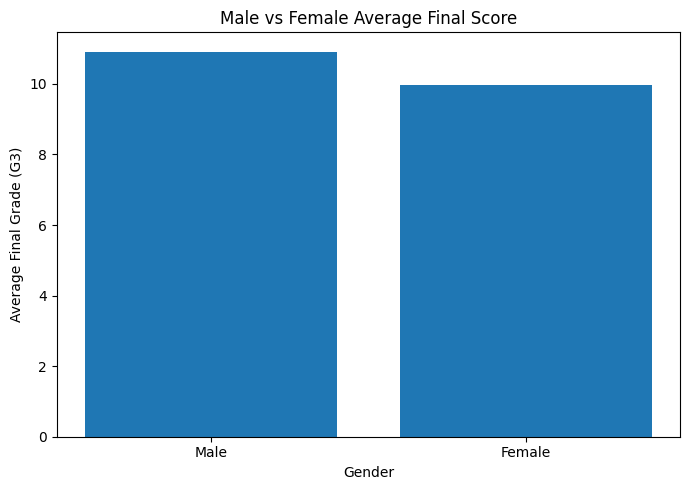

In [6]:
gender_avg_plot = clean_df.groupby("sex")["G3"].mean().reindex(["M", "F"])
gender_avg_plot.index = gender_avg_plot.index.map({"M": "Male", "F": "Female"})

plt.figure(figsize=(7, 5))
plt.bar(gender_avg_plot.index, gender_avg_plot.values)
plt.title("Male vs Female Average Final Score")
plt.xlabel("Gender")
plt.ylabel("Average Final Grade (G3)")
plt.tight_layout()
plt.show()

### Conclusion from Visualization 3: Male vs Female Average Score

The bar chart visually confirms the finding from the numerical analysis: **male students have a higher average final grade compared to female students** in this dataset. The difference, while not extremely large, is noticeable, suggesting a gender-based disparity in academic performance for final grades.

## 7) Final notes / conclusion


### Final Conclusion

This analysis of student performance data revealed several key insights:

*   The average final grade (G3) among students is approximately **10.42**.
*   Only a small portion of students (40 out of 395) managed to score above 15, indicating that high performance is less common.
*   While there is a **weak positive correlation between study time and final grades**, study time doesn't appear to be a dominant factor in determining success. Other variables might be more influential.
*   A gender difference was observed, with **male students achieving a slightly higher average final grade** than female students.

Overall, the data suggests a typical distribution of academic performance with a tendency towards lower grades, and highlights potential areas for further investigation into factors influencing student success, particularly the observed gender gap and the relatively minor impact of study time on final grades.